In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
print(os.getcwd())



no file_setting specificied


/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/files_for_Dufour/'
M0703_file='ravg_fwctb.GaiaJ1644m0449_20190703_400m2.fits'
M0729_file='ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits'
M0825_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
print(model_spec_file)

J1644_fit_flambda.dms


In [3]:
os.chdir(target_dir)

In [4]:
model_spec=spt.retrieve_model_spec(model_spec_file)

In [5]:
print(os.getcwd())

/Users/BenKaiser/Desktop/files_for_Dufour


In [6]:
M0703_spec, header, target_noise= spt.retrieve_spec(M0703_file)
M0729_spec, header, target_noise= spt.retrieve_spec(M0729_file)
M0825_spec, header, target_noise= spt.retrieve_spec(M0825_file)


In [7]:
sm_M0703_spec= ps.convolve_spectrum(M0703_spec, header, kernel_type='box', pix_width=3)
sm_M0729_spec= ps.convolve_spectrum(M0729_spec, header, kernel_type='box', pix_width=3)
sm_M0825_spec= ps.convolve_spectrum(M0825_spec, header, kernel_type='box',pix_width=3)


Now I want to normalize these spectra before I even try to plot them because fuck it.

In [8]:
norm_range=[6630, 6690]

In [9]:
sm_M0703_spec= ps.norm_spectrum(sm_M0703_spec, norm_range, show_norm_range=False)
sm_M0729_spec= ps.norm_spectrum(sm_M0729_spec, norm_range, show_norm_range=False)
sm_M0825_spec= ps.norm_spectrum(sm_M0825_spec, norm_range, show_norm_range=False)



wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





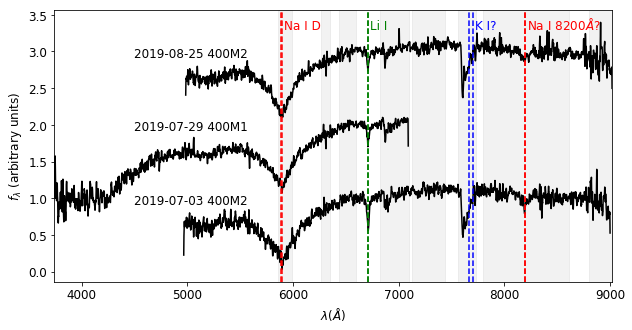

In [10]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0703_spec[0],sm_M0703_spec[1], color='k')
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1]+1,  color='k')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1]+2, color='k')

plt.text(x_pos, y_pos, '2019-07-03 400M2', color='k')
plt.text(x_pos, y_pos+1, '2019-07-29 400M1', color='k')
plt.text(x_pos, y_pos+2, '2019-08-25 400M2', color='k')






plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
#plt.ylim(-0.05, 0.3)
plt.axvline(x=5889.950866765008, linestyle='--', color='r')
plt.axvline(x=5895.9241497669427, linestyle='--', color='r')
plt.text(5895.9241497669427+label_off, label_pos,'Na I D', color='r')

plt.axvline(x=6707.7580436285689, linestyle='--', color='g')
plt.axvline(x=6707.9080032878719, linestyle='--', color='g')
plt.text(6707.9080032878719+label_off, label_pos,'Li I', color='g')


plt.axvline(x=7664.8990160014137, linestyle='--', color='b')
plt.axvline(x=7698.9644515250075, linestyle='--', color='b')
plt.text(7698.9644515250075+label_off, label_pos,'K I?', color='b')

plt.axvline(x=8194.7903983717824, linestyle='--', color='r')
plt.axvline(x=8194.8235894019599, linestyle='--', color='r')
plt.text(8194.8235894019599+label_off, label_pos,r'Na I $8200\AA$?', color='r')

plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='', show_legend=False)

/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


/Users/BenKaiser/Desktop/Goodman_ref_files/line_lists/alkali_lines_vac.csv
wavelengths.min:  5891.583264
new_wavelengths.min(): 5889.95086677
wavelengths.min:  5897.558147
new_wavelengths.min(): 5895.92414977
wavelengths.min:  6709.61
new_wavelengths.min(): 6707.75804363
wavelengths.min:  6709.76
new_wavelengths.min(): 6707.90800329
wavelengths.min:  7667.008906
new_wavelengths.min(): 7664.899016
wavelengths.min:  7701.083536
new_wavelengths.min(): 7698.96445153
wavelengths.min:  8185.5054
new_wavelengths.min(): 8183.25551561
wavelengths.min:  8197.0434
new_wavelengths.min(): 8194.79039837
wavelengths.min:  8197.0766
new_wavelengths.min(): 8194.8235894


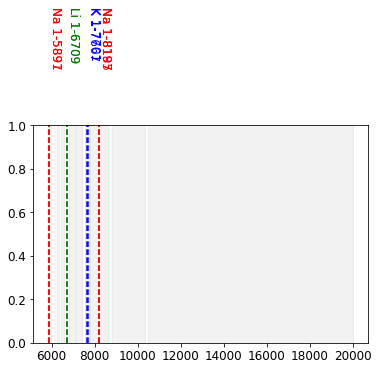

In [11]:
spt.show_plot(line_id='alkali', convert_to_air=True)

I want to use the unsmoothed versions for the zoomed in portion I think.

In [12]:
n_M0703= ps.norm_spectrum(M0703_spec, norm_range, show_norm_range=False)
n_M0729= ps.norm_spectrum(M0729_spec, norm_range, show_norm_range=False)
n_M0825= ps.norm_spectrum(M0825_spec, norm_range, show_norm_range=False)



wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





In [13]:
side=200.
li_min=6708-side
li_max=6708+side
#li_M0703=spt.clean_spectrum(sm_M0703_spec,li_min, li_max, [])
#li_M0729=spt.clean_spectrum(sm_M0729_spec,li_min, li_max, [])
#li_M0825=spt.clean_spectrum(sm_M0825_spec,li_min, li_max, [])
li_M0703=spt.clean_spectrum(n_M0703,li_min, li_max, [])
li_M0729=spt.clean_spectrum(n_M0729,li_min, li_max, [])
li_M0825=spt.clean_spectrum(n_M0825,li_min, li_max, [])

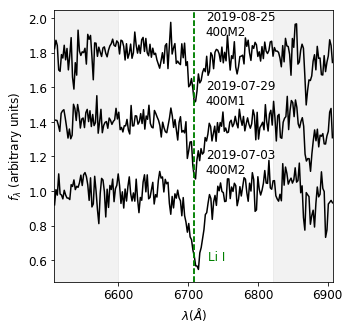

In [14]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(5,5))
label_pos=0.6
label_off=20
x_pos= 6725
y_pos= 1.1
plt.plot(li_M0703[0],li_M0703[1], color='k')
plt.plot(li_M0729[0],li_M0729[1]+0.4,  color='k')
plt.plot(li_M0825[0],li_M0825[1]+0.8, color='k')

plt.text(x_pos, y_pos, '2019-07-03\n400M2', color='k')
plt.text(x_pos, y_pos+0.4, '2019-07-29\n400M1', color='k')
plt.text(x_pos, y_pos+0.8, '2019-08-25\n400M2', color='k')






#plt.ylim(-0.05, 0.3)

plt.axvline(x=6707.7580436285689, linestyle='--', color='g')
plt.axvline(x=6707.9080032878719, linestyle='--', color='g')
plt.text(6707.9080032878719+label_off, label_pos,'Li I', color='g')


plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
plt.xlim((li_min, li_max))


spt.show_plot(line_id='', show_legend=False)

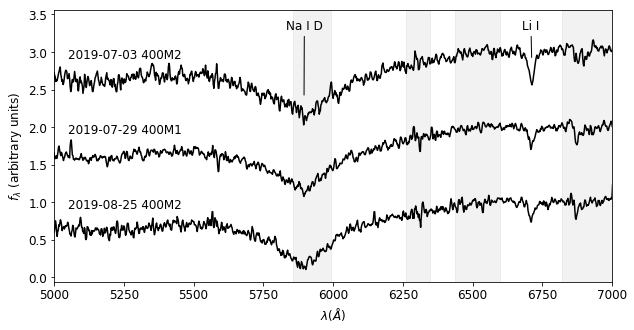

In [15]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,5))
label_pos=3.3
label_off=65
x_pos= 5050
y_pos= 0.92
plt.plot(sm_M0703_spec[0],sm_M0703_spec[1]+2, color='k')
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1]+1,  color='k')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')

plt.text(x_pos, y_pos+2, '2019-07-03 400M2', color='k')
plt.text(x_pos, y_pos+1, '2019-07-29 400M1', color='k')
plt.text(x_pos, y_pos, '2019-08-25 400M2', color='k')






#plt.xlim(np.nanmin(sm_M0729_spec[0]), np.nanmax([sm_M0703_spec[0], sm_M0825_spec[0]]))
plt.xlim(5000, 7000)

#plt.ylim(-0.05, 0.3)

plt.annotate('Na I D',xy=(5895.9241497669427, 2.4),xytext=(5895.9241497669427-label_off, label_pos), arrowprops=dict(arrowstyle='-'))

plt.annotate('Li I',xy=(6707.9080032878719+4, 2.9),xytext=(6707.9080032878719-30, label_pos), arrowprops=dict(arrowstyle='-'))



plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')
#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='', show_legend=False)

In [16]:
model_spec= ps.norm_spectrum(model_spec, norm_range, show_norm_range=False)



wavelength-based norm range selected [6630, 6690]





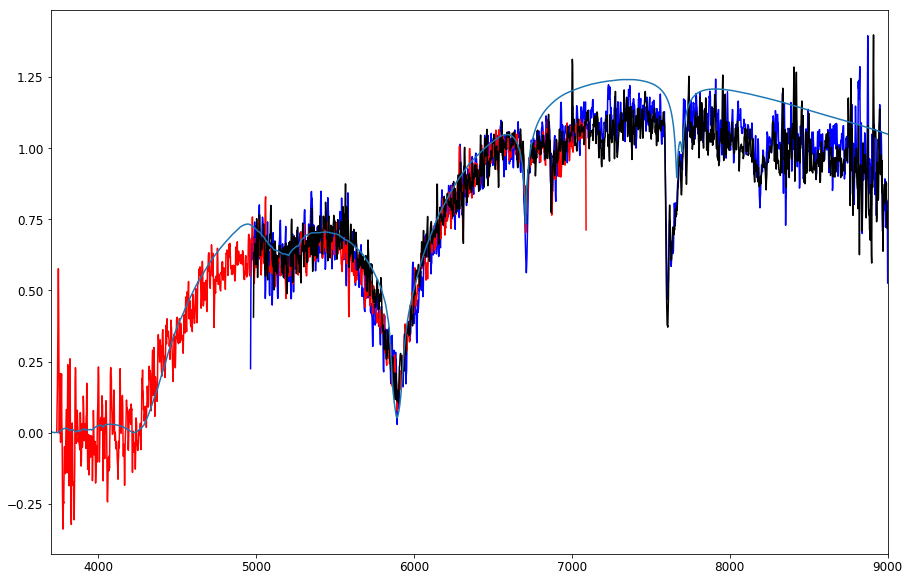

In [20]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0703_spec[0],sm_M0703_spec[1], color='b', label='2019-07-03')
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='r', label='2019-07-29')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k', label='2019-08-25')
plt.plot(model_spec[0], model_spec[1], label='Model')
plt.legend()

plt.xlim(3700,9000)
plt.show()


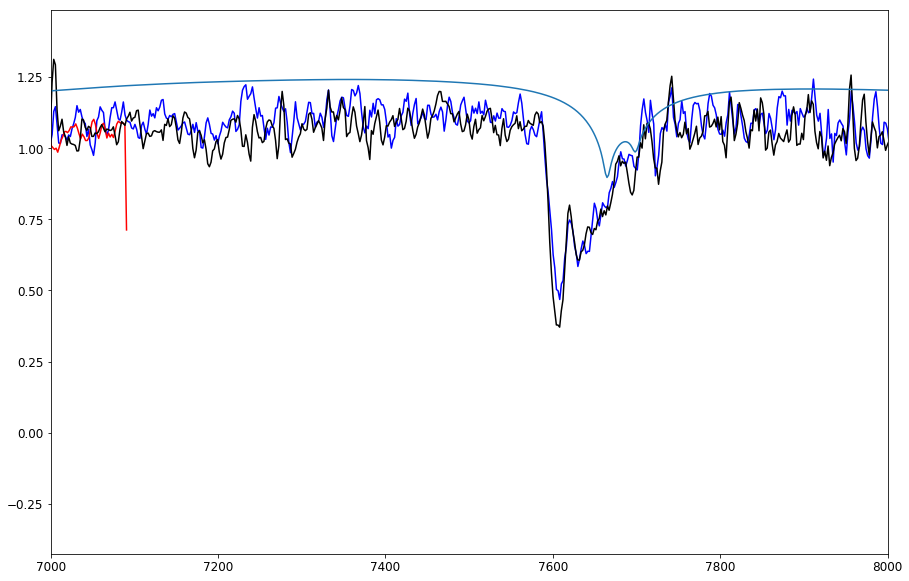

In [21]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0703_spec[0],sm_M0703_spec[1], color='b')
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='r')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')
plt.plot(model_spec[0], model_spec[1])

plt.xlim(7000,8000)
plt.show()



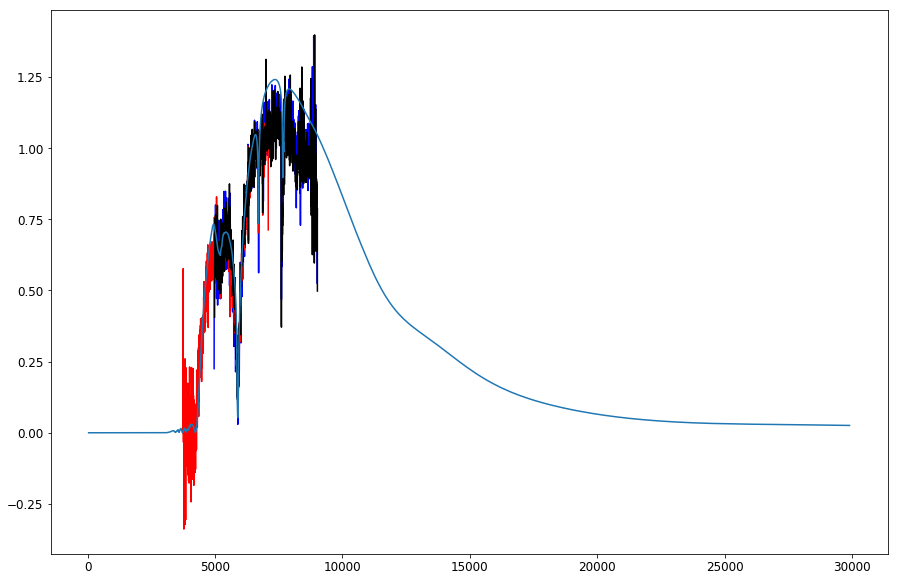

In [22]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(15,10))
label_pos=3.3
label_off=20
x_pos= 4500
y_pos= 0.92
plt.plot(sm_M0703_spec[0],sm_M0703_spec[1], color='b')
plt.plot(sm_M0729_spec[0],sm_M0729_spec[1],  color='r')
plt.plot(sm_M0825_spec[0],sm_M0825_spec[1], color='k')
plt.plot(model_spec[0], model_spec[1])

plt.show()


